# Text Processing and Linguistic Analysis

## Setup

Run once. The spaCy model is ~12 MB.

In [7]:
# %pip install -q nltk spacy matplotlib
# !python -m spacy download en_core_web_sm

In [8]:
import nltk
import matplotlib.pyplot as plt

# for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4",
#             "gutenberg", "averaged_perceptron_tagger",
#             "averaged_perceptron_tagger_eng"]:
#     nltk.download(pkg, quiet=True)

# print("done")

## Strings

A string is an immutable, ordered sequence of characters. Immutable means you
never modify one: every operation returns a **new** string.

In [9]:
s = "Text Analytics"

print(s[0], s[-1])        # indexing is 0-based; negative counts from the end
print(s[0:4])             # slicing [start:end]
print(s[::-1])            # step -1 reverses

# s[0] = "t"                # raises TypeError: strings are immutable

T s
Text
scitylanA txeT


The operations every language gives you: case, whitespace, search, split, join.

In [10]:
sample = "  Pool rules matter.  \nA lot"

print(sample)
print()

print(sample.strip())     # trim whitespace, displays the exact string representation, including quotes and escaped characters
print()

print(repr(sample.strip()))       # trim whitespace, displays the exact string representation, including quotes and escaped characters
print()

print(sample.lower())
print()

print(sample.strip().split())     # split on whitespace -> list of words
print()

print("-".join(["a", "b", "c"]))
print()

print(sample.replace("Pool", "Beach"))
print()

  Pool rules matter.  
A lot

Pool rules matter.  
A lot

'Pool rules matter.  \nA lot'

  pool rules matter.  
a lot

['Pool', 'rules', 'matter.', 'A', 'lot']

a-b-c

  Beach rules matter.  
A lot



A useful method to check if a string is alphabetic is `.alpha`
A string is alphabetic if all characters in the string are alphabetic and there is at least one character in the string.

In [94]:
print("10", "10".isalpha())
print("ciao", "ciao".isalpha())
print("ciao!", "ciao!".isalpha())
print("user_name", "user_name".isalpha())

10 False
ciao True
ciao! False
user_name False


### Encodings

Text in memory is a sequence of Unicode **code points**. To write it to a file
or send it over a network it has to be **encoded** into bytes. UTF-8 is the
default and encodes ASCII in one byte, other characters in two to four.

In [11]:
s = "città"

print(len(s), "characters")
print(s.encode("utf-8"), len(s.encode("utf-8")), "bytes in UTF-8")
print(s.encode("utf-16"), len(s.encode("utf-16")), "bytes in UTF-16")

# The wrong encoding does not fail politely, it produces the wrong text.
print(s.encode("utf-8").decode("latin-1"))

5 characters
b'citt\xc3\xa0' 6 bytes in UTF-8
b'\xff\xfec\x00i\x00t\x00t\x00\xe0\x00' 12 bytes in UTF-16
cittÃ 


## Regular expressions

String methods find **fixed** substrings. A regular expression describes a
**pattern**. Note the `r"..."` prefix: a raw string, so that `\d` reaches the
regex engine instead of being interpreted by Python first.

In [21]:
import re

text = "Pisa was founded in 1343, Bologna in 1088."

# re.findall() finds all non-overlapping matches and returns a list.
print(re.findall(r"\d+", text))  # one or more digits

# re.search() finds the first match and returns a Match object, or None.
print(re.search(r"\d{4}", text).group())  # first four-digit run

# re.sub() replaces regex matches with new text.
print(re.sub(r"\d+", "####", text))  # substitution

['1343', '1088']
1343
Pisa was founded in ####, Bologna in ####.


In [24]:
print(re.findall(r"^Pool",  "Pool rules matter"))   # anchored at the start
print(re.findall(r"a{2,3}",  "caaaat"))             # 2 to 3 a's
print(re.findall(r"[aeiou]", "hello world"))        # vowels
print(re.findall(r"[^aeiou\s]", "hello world"))     # everything but vowels
print(re.findall(r"cat|dog",  "a cat and a dog"))   # alternation

['Pool']
['aaa']
['e', 'o', 'o']
['h', 'l', 'l', 'w', 'r', 'l', 'd']
['cat', 'dog']


**Capture groups** are what turn a regex from *find* into *extract*.

In [28]:
log = "2026-03-14 ERROR disk full"

# re.match() it's a convenience method and returns a match only if the pattern occurs at the beginning of the string.
m = re.match(r"(\d{4})-(\d{2})-(\d{2}) (\w+) (.*)", log)
print(m.group(1), m.group(4), m.group(5))

# Groups can be referred to in a replacement, by number.
print(re.sub(r"(\w+) (\w+)", r"\2 \1", "Hello World"))

2026 ERROR disk full
World Hello


**Exercise.** Write one regex that finds every year in `text` that is
before 1200. Then write one that finds words ending in *-ing*.

In [97]:
# your turn

## Corpus, Sentences, and Tokens

A corpus is a collection of texts. We use *Alice in Wonderland* from the
Gutenberg corpus bundled with NLTK: one document, English, 1865, prose
fiction. Every one of those facts affects what we are about to measure.

In [29]:
from nltk.corpus import gutenberg

print(gutenberg.fileids())

['austen-emma.txt', 'austen-persuasion.txt', 'austen-sense.txt', 'bible-kjv.txt', 'blake-poems.txt', 'bryant-stories.txt', 'burgess-busterbrown.txt', 'carroll-alice.txt', 'chesterton-ball.txt', 'chesterton-brown.txt', 'chesterton-thursday.txt', 'edgeworth-parents.txt', 'melville-moby_dick.txt', 'milton-paradise.txt', 'shakespeare-caesar.txt', 'shakespeare-hamlet.txt', 'shakespeare-macbeth.txt', 'whitman-leaves.txt']


In [30]:
raw = gutenberg.raw("carroll-alice.txt")
print(len(raw), "characters")

144395 characters


In [31]:
print(raw[:300])

[Alice's Adventures in Wonderland by Lewis Carroll 1865]

CHAPTER I. Down the Rabbit-Hole

Alice was beginning to get very tired of sitting by her sister on the
bank, and of having nothing to do: once or twice she had peeped into the
book her sister was reading, but it had no pictures or conversatio


### Sentences

#### NLTK

In [32]:
sentences = nltk.sent_tokenize(raw)
print(len(sentences), "sentences")

1625 sentences


In [33]:
print(sentences[10])

First, she tried to look down and make out what
she was coming to, but it was too dark to see anything; then she
looked at the sides of the well, and noticed that they were filled with
cupboards and book-shelves; here and there she saw maps and pictures
hung upon pegs.


In [35]:
for s in sentences[10:13]:
    print(">", s.replace("\n", " "))

> First, she tried to look down and make out what she was coming to, but it was too dark to see anything; then she looked at the sides of the well, and noticed that they were filled with cupboards and book-shelves; here and there she saw maps and pictures hung upon pegs.
> She took down a jar from one of the shelves as she passed; it was labelled 'ORANGE MARMALADE', but to her great disappointment it was empty: she did not like to drop the jar for fear of killing somebody, so managed to put it into one of the cupboards as she fell past it.
> 'Well!'


Sentence splitting is not just splitting on `.` — abbreviations and initials break that.

In [36]:
naive  = "I'll take the 8.30 train to St. Louis. Time will tell!".split(".")
smart  = nltk.sent_tokenize("I'll take the 8.30 train to St. Louis. Time will tell!")

print("naive :", naive)
print("smart :", smart)

naive : ["I'll take the 8", '30 train to St', ' Louis', ' Time will tell!']
smart : ["I'll take the 8.30 train to St. Louis.", 'Time will tell!']


In [38]:
sentences_lengths = [len(s) for s in sentences]
sentences_lengths[:30]

[68,
 323,
 289,
 140,
 8,
 17,
 565,
 109,
 219,
 162,
 269,
 271,
 7,
 100,
 39,
 80,
 29,
 17,
 36,
 51,
 15,
 58,
 416,
 106,
 26,
 50,
 86,
 204,
 49,
 91]

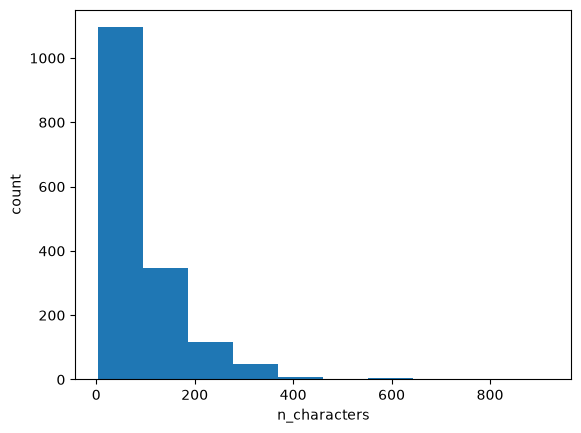

In [39]:
plt.hist(sentences_lengths)
plt.xlabel("n_characters")
plt.ylabel("count")
plt.plot()
plt.show()

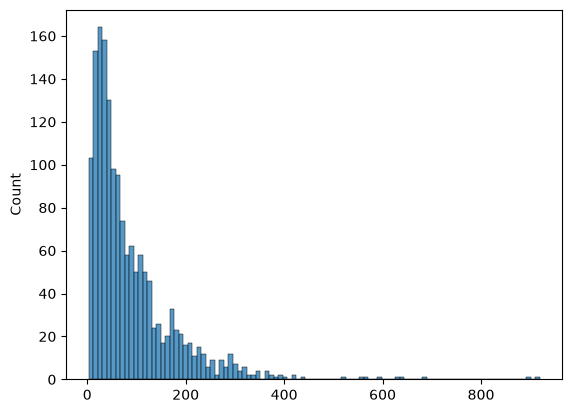

In [42]:
import seaborn as sns
sns.histplot(sentences_lengths, bins=100)
plt.show()

#### Spacy

In [43]:
import spacy
nlp = spacy.load("en_core_web_sm")

In [44]:
# takes a few seconds
alice_nlp = nlp(raw)

In [46]:
for i, sent in enumerate(alice_nlp.sents):
    print(str(i) + " --- \n", sent)

    if i == 4:
        break

0 --- 
 [Alice's Adventures in Wonderland by Lewis Carroll 1865]

CHAPTER I. Down the Rabbit-Hole

Alice was beginning to get very tired of sitting by her sister on the
bank, and of having nothing to do: once or twice she had peeped into the
book her sister was reading, but it had no pictures or conversations in
it, 'and what is the use of a book,' thought Alice 'without pictures or
conversation?'


1 --- 
 So she was considering in her own mind (as well as she could, for the
hot day made her feel very sleepy and stupid), whether the pleasure
of making a daisy-chain would be worth the trouble of getting up and
picking the daisies, when suddenly a White Rabbit with pink eyes ran
close by her.


2 --- 
 There was nothing so VERY remarkable in that; nor did Alice think it so
VERY much out of the way to hear the Rabbit say to itself, 'Oh dear!

3 --- 
 Oh dear!
4 --- 
 I shall be late!'


In [47]:
test = list(alice_nlp.sents)

### Tokens
Here we just use word tokenization. `ntlk` and `spacy` do not support sub-word tokenization. In data understanding and preprocessing for linguistic tasks word tokenization is usually better. We will see sub-word tokenization later in this course.

In [55]:
tokens = nltk.word_tokenize(raw)

In [56]:
print(len(tokens), "tokens")

34440 tokens


In [57]:
print(tokens[:25])

['[', 'Alice', "'s", 'Adventures', 'in', 'Wonderland', 'by', 'Lewis', 'Carroll', '1865', ']', 'CHAPTER', 'I', '.', 'Down', 'the', 'Rabbit-Hole', 'Alice', 'was', 'beginning', 'to', 'get', 'very', 'tired', 'of']


Notice what the tokenizer did: it split `n't` off `did`, and made every
punctuation mark its own token. That is the Penn Treebank standard.

In [58]:
print(nltk.word_tokenize("The San Francisco-based restaurant doesn't charge $10."))

['The', 'San', 'Francisco-based', 'restaurant', 'does', "n't", 'charge', '$', '10', '.']


In [59]:
tokens_spacy = list(alice_nlp)
tokens_spacy[:30]

[[,
 Alice,
 's,
 Adventures,
 in,
 Wonderland,
 by,
 Lewis,
 Carroll,
 1865,
 ],
 
 ,
 CHAPTER,
 I.,
 Down,
 the,
 Rabbit,
 -,
 Hole,
 
 ,
 Alice,
 was,
 beginning,
 to,
 get,
 very,
 tired,
 of,
 sitting,
 by]

In [60]:
tokens_spacy[20], type(tokens_spacy[20])

(Alice, spacy.tokens.token.Token)

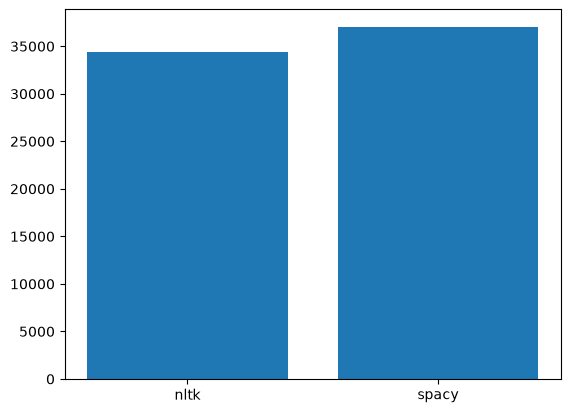

In [61]:
plt.bar(["nltk", "spacy"], [len(tokens), len(tokens_spacy)])
plt.show()

In [62]:
tokens_spacy_nospaces = [t for t in tokens_spacy if not t.is_space]
len(tokens_spacy_nospaces)

34503

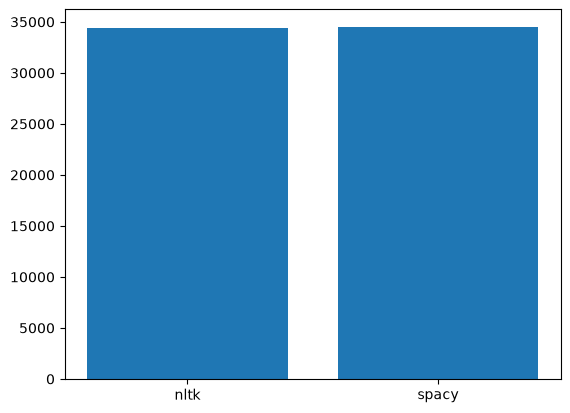

In [63]:
plt.bar(["nltk", "spacy"], [len(tokens), len(tokens_spacy_nospaces)])
plt.show()

In [64]:
tokens_per_sentence = [len(nltk.word_tokenize(s)) for s in sentences]

Text(0.5, 0, 'n_tokens')

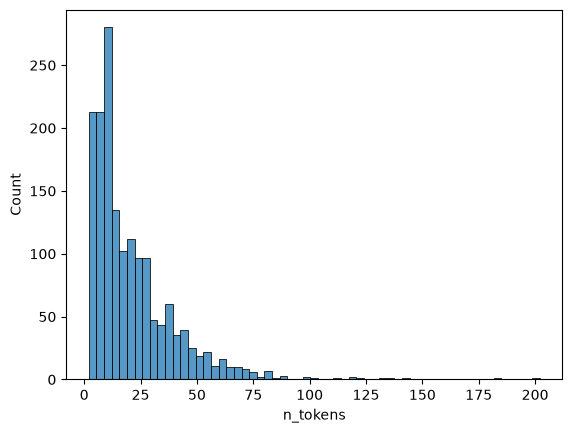

In [65]:
sns.histplot(tokens_per_sentence)
plt.xlabel("n_tokens")

In [67]:
tokens_per_sentence_spacy = [sum(1 for t in sent if not t.is_space) for sent in alice_nlp.sents]

Text(0.5, 0, 'n_tokens')

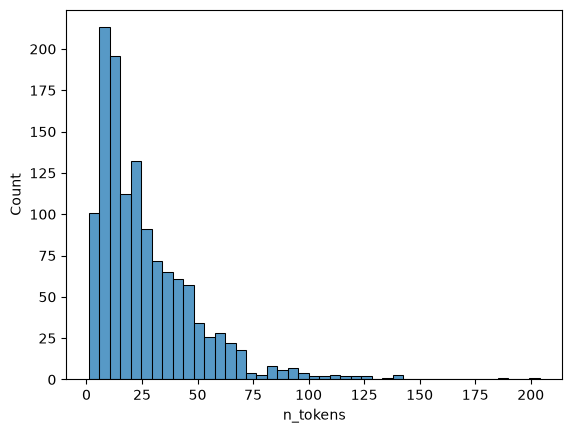

In [68]:
sns.histplot(tokens_per_sentence_spacy)
plt.xlabel("n_tokens")

## Types and the vocabulary

$|C|$ is the number of tokens, $V$ the set of distinct types, $|V|$ its size.

In [69]:
from collections import Counter

freq = Counter(tokens)

We have used Python’s `Counter` to count word occurrences.  
NLTK provides its own class `FreqDist` which offers similar functionality but with extra methods useful for linguistic analysis and visualization.

`FreqDist` takes a list of tokens and builds a frequency distribution (i.e., a mapping between each token and its number of occurrences).

It works like `Counter`, but allows direct access to methods such as:
- `.most_common(n)`: top-n most frequent tokens  
- `.plot(n)`: frequency plot  
- `.hapaxes()`: words that appear only once

In [74]:
freq = nltk.FreqDist(tokens)

print("|C| =", len(tokens))
print("|V| =", len(freq))
print(freq.most_common(15))

|C| = 34440
|V| = 2995
[(',', 2418), ("'", 2219), ('the', 1522), ('.', 975), ('and', 796), ('to', 721), ('a', 614), ('I', 543), ('it', 527), ('she', 509), ('of', 497), ('said', 456), ('!', 450), ('Alice', 396), ('was', 363)]


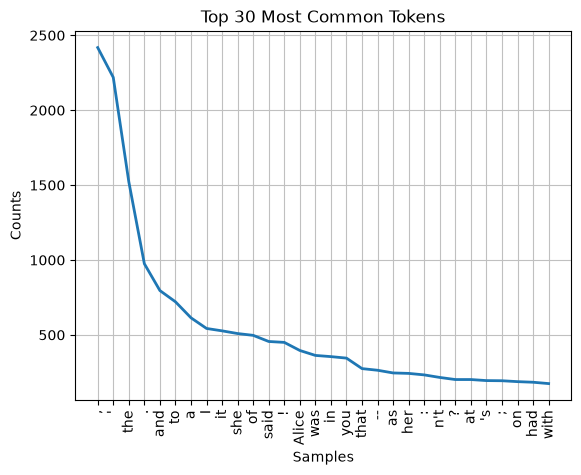

In [75]:
freq.plot(30, title='Top 30 Most Common Tokens')
plt.show()

$V$ is not a property of the text alone. Case-folding changes it.

In [76]:
lower = nltk.FreqDist(t.lower() for t in tokens)

print("|V| as-is      :", len(freq))
print("|V| case-folded:", len(lower))
print("difference     :", len(freq) - len(lower))

|V| as-is      : 2995
|V| case-folded: 2622
difference     : 373


In [78]:
# !pip install wordcloud

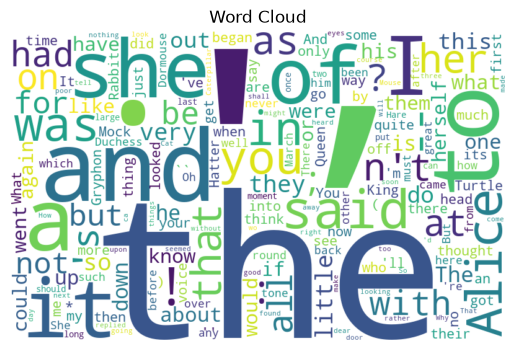

In [79]:
from wordcloud import WordCloud

plt.imshow(WordCloud(width=800, height=500, background_color="white").generate_from_frequencies(freq), interpolation="bilinear")
plt.title("Word Cloud")
plt.gca().axis("off")
plt.show()


## Zipf's law

Zipf: frequency is inversely proportional to rank, $f \propto 1/r$. On
log-log axes that is a straight line with slope $-1$.

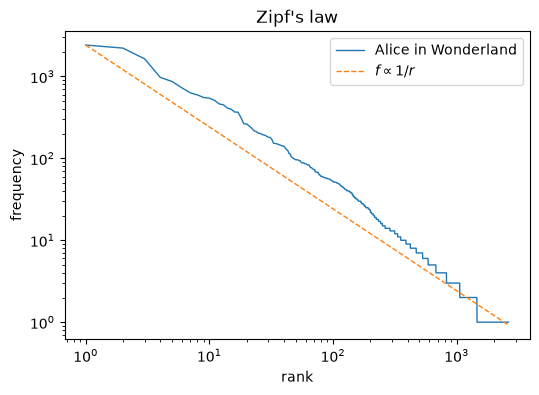

In [ ]:
import matplotlib.pyplot as plt

counts = [c for _, c in lower.most_common()]
ranks  = range(1, len(counts) + 1)

plt.figure(figsize=(6, 4))
plt.loglog(ranks, counts, linewidth=1, label="Alice in Wonderland")
plt.loglog(ranks, [counts[0] / r for r in ranks], "--", linewidth=1, label=r"$f \propto 1/r$")
plt.xlabel("rank")
plt.ylabel("frequency")
plt.legend()
plt.title("Zipf's law")
plt.show()

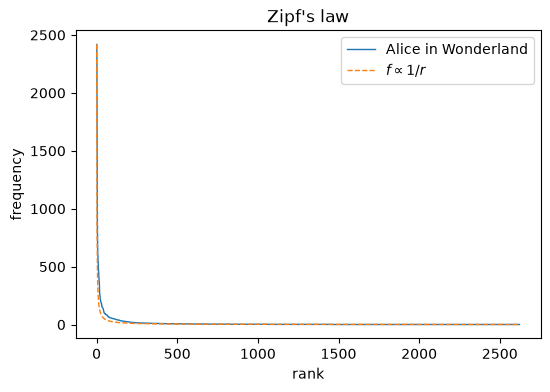

In [ ]:
import matplotlib.pyplot as plt

counts = [c for _, c in lower.most_common()]
ranks  = range(1, len(counts) + 1)

plt.figure(figsize=(6, 4))
plt.plot(ranks, counts, linewidth=1, label="Alice in Wonderland")
plt.plot(ranks, [counts[0] / r for r in ranks], "--", linewidth=1, label=r"$f \propto 1/r$")
plt.xlabel("rank")
plt.ylabel("frequency")
plt.legend()
plt.title("Zipf's law"); plt.show()

### Herdan's (Heaps') law

$|V| = k\,|C|^{\beta}$ with $0 < \beta < 1$: the vocabulary grows, but ever
more slowly. Read the first $n$ tokens and count the types seen so far.

fitted beta = 0.565   (the book reports 0.44 to 0.56)


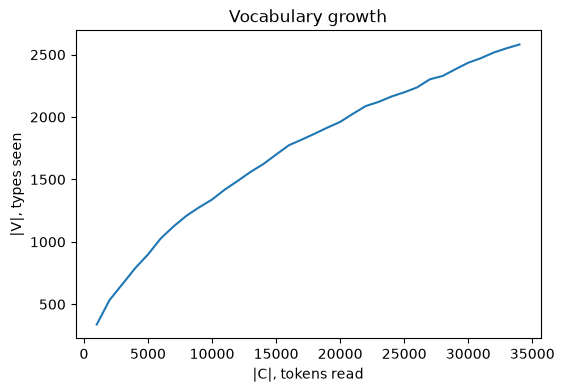

In [ ]:
import numpy as np

step = 1000
checkpoints = list(range(step, len(tokens), step))
marks = set(checkpoints)

seen, sizes = set(), []  # vocabulary, size of the vocabulary at checkpoints
for i, tok in enumerate(t.lower() for t in tokens):
    seen.add(tok)  # we add to the set (so no duplicates)
    if i + 1 in marks:  # when we are at a checkpoint
        sizes.append(len(seen))  # we append the length of the vocabulary

beta, logk = np.polyfit(np.log(checkpoints), np.log(sizes), 1)
print(f"fitted beta = {beta:.3f}   (the book reports 0.44 to 0.56)")

plt.figure(figsize=(6, 4))
plt.plot(checkpoints, sizes)
plt.xlabel("|C|, tokens read")
plt.ylabel("|V|, types seen")
plt.title("Vocabulary growth")
plt.show()

## Stopwords and rare words

Zipf's two tails. The head is a handful of words carrying almost no content;
the tail is a mass of words we have almost no evidence about.

In [105]:
from nltk.corpus import stopwords

sw = set(stopwords.words("english"))
print(len(sw), "English stopwords:", sorted(sw)[:15])

198 English stopwords: ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't"]


In [111]:
kept = [t for t in (t for t in tokens) if t.isalpha() and t.lower() not in sw]
print(f"tokens before: {len(tokens)}   after: {len(kept)}")
print(nltk.FreqDist(kept).most_common(15))

tokens before: 34440   after: 12073
[('said', 456), ('Alice', 396), ('little', 125), ('one', 94), ('know', 87), ('like', 84), ('went', 83), ('could', 82), ('would', 82), ('thought', 74), ('Queen', 74), ('see', 66), ('time', 65), ('King', 61), ('Turtle', 59)]


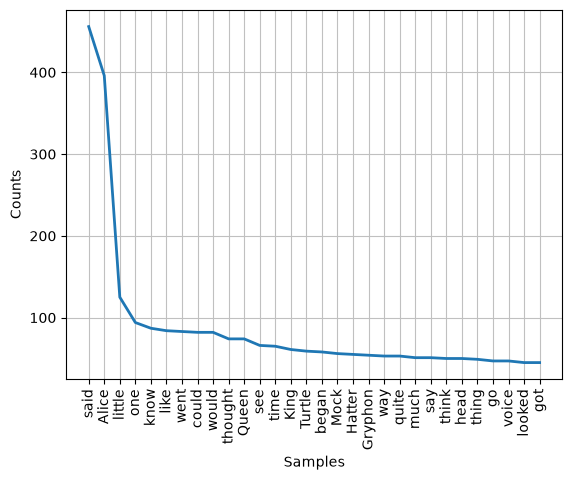

In [112]:
nltk.FreqDist(kept).plot(30)
plt.plot()
plt.show()

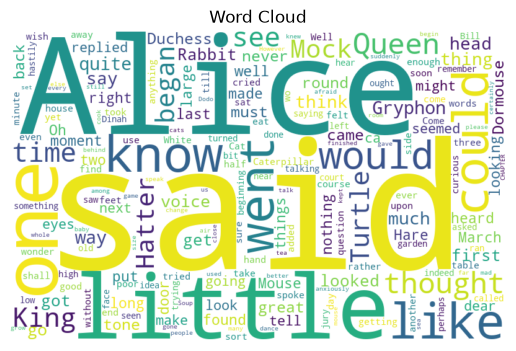

In [113]:
from wordcloud import WordCloud

freq_kept = {k: freq[k] for k in kept}
plt.imshow(
    WordCloud(width=800, height=500, background_color="white", random_state=0).generate_from_frequencies(freq_kept), interpolation="bilinear"
    )
plt.title("Word Cloud")
plt.gca().axis("off")
plt.show()

In [116]:
features = set(nltk.word_tokenize('devo andare al mare altrimenti mi deprimo'))
less_features = features.difference(stopwords.words('italian'))
less_features

{'altrimenti', 'andare', 'deprimo', 'devo', 'mare'}

**Hapax legomena**: types occurring exactly once. Usually about half the vocabulary.

In [121]:
lower = nltk.FreqDist([t.lower() for t in tokens])
hapaxes = lower.hapaxes()
print(f"{len(hapaxes)} hapaxes out of {len(lower)} types "
      f"({100 * len(hapaxes) / len(lower):.0f}% of the vocabulary)")
print(hapaxes[:20])

1166 hapaxes out of 2622 types (44% of the vocabulary)
['lewis', 'carroll', '1865', 'conversations', 'daisy-chain', 'daisies', 'pink', 'wondered', 'actually', 'flashed', 'burning', 'field', 'fortunately', 'pop', 'tunnel', 'stopping', 'book-shelves', 'maps', 'hung', 'pegs']


## Stemming and lemmatization

A stemmer chops affixes by rule and needs to know nothing. A lemmatizer looks
the word up in a lexicon, and needs its part of speech.

In [122]:
from nltk.stem.porter import PorterStemmer
from nltk.stem.wordnet import WordNetLemmatizer

stemmer, lemmatizer = PorterStemmer(), WordNetLemmatizer()

for w in ["cars", "studies", "was", "better", "operating"]:
    print(f"{w:12} stem={stemmer.stem(w):10} lemma={lemmatizer.lemmatize(w)}")

cars         stem=car        lemma=car
studies      stem=studi      lemma=study
was          stem=wa         lemma=wa
better       stem=better     lemma=better
operating    stem=oper       lemma=operating


Two things to notice. The stemmer's output is often **not a word**
(*studi*). And it cannot relate *was* to *be*: that needs the lexicon, and the
part of speech.

In [ ]:
print(lemmatizer.lemmatize("was"))  # no POS: assumes noun, gives 'wa', e.g., "We must focus on the future and forget the was."
print(lemmatizer.lemmatize("was", pos="v")) # told it is a verb: 'be'
print(lemmatizer.lemmatize("better", pos="a"))  # adjective: 'good'
print(lemmatizer.lemmatize("better", pos="v"))  # verb

wa
be
good
better


## POS tagging

The same wordform can be different parts of speech. Tagging resolves it from
context, which is why lemmatization wants a tagger in front of it.

In [123]:
for sent in ["I saw a bird.", "Can you lend me a saw?"]:
    print(nltk.pos_tag(nltk.word_tokenize(sent)))

[('I', 'PRP'), ('saw', 'VBD'), ('a', 'DT'), ('bird', 'NN'), ('.', '.')]
[('Can', 'MD'), ('you', 'PRP'), ('lend', 'VB'), ('me', 'PRP'), ('a', 'DT'), ('saw', 'NN'), ('?', '.')]


`NN` is a noun, `VBD` a past-tense verb. That is the Penn Treebank tagset, 45 tags.

In [124]:
nltk.help.upenn_tagset("NN")

NN: noun, common, singular or mass
    common-carrier cabbage knuckle-duster Casino afghan shed thermostat
    investment slide humour falloff slick wind hyena override subhumanity
    machinist ...


## Annotations

One call runs the whole pipeline and attaches every layer to each token.

In [125]:
doc = nlp("The quick fox jumped over the lazy dog. "
          "Francesco Spinnato is a researcher at the University of Pisa, in Pisa")

print(f"{'text':12}{'lemma':12}{'POS':8}{'dep':12}{'head':12}")
print("-" * 50)
for t in list(doc)[:9]:
    print(f"{t.text:12}{t.lemma_:12}{t.pos_:8}{t.dep_:12}{t.head.text:12}")

text        lemma       POS     dep         head        
--------------------------------------------------
The         the         DET     det         fox         
quick       quick       ADJ     amod        fox         
fox         fox         NOUN    nsubj       jumped      
jumped      jump        VERB    ROOT        jumped      
over        over        ADP     prep        jumped      
the         the         DET     det         dog         
lazy        lazy        ADJ     amod        dog         
dog         dog         NOUN    pobj        over        
.           .           PUNCT   punct       jumped      


### BIO tags

Spans become one label per token. This is the encoding the lecture describes,
and spaCy exposes it directly.

In [145]:
second = list(doc.sents)[1]

for t in second:
    tag = f"{t.ent_iob_}-{t.ent_type_}" if t.ent_type_ else "O"
    print(f"{t.text:16}{tag}")

Francesco       B-PERSON
Spinnato        I-PERSON
is              O
a               O
researcher      O
at              O
the             B-ORG
University      I-ORG
of              I-ORG
Pisa            I-ORG
,               O
in              O
Pisa            B-ORG


### Named entities

Each entity is a **span**, with a type and character offsets.

In [146]:
for ent in doc.ents:
    print(f"{ent.text:24}{ent.label_:8}{ent.start_char}-{ent.end_char}")

fox                     ORG     10-13
Francesco Spinnato      PERSON  40-58
the University of Pisa  ORG     78-100
Pisa                    ORG     105-109


In [128]:
from spacy import displacy
displacy.render(doc, style="ent", jupyter=True)

In [130]:
labels_in_text = {ent.label_ for ent in alice_nlp.ents}
labels_in_text

{'CARDINAL',
 'DATE',
 'EVENT',
 'FAC',
 'GPE',
 'LANGUAGE',
 'LAW',
 'LOC',
 'NORP',
 'ORDINAL',
 'ORG',
 'PERSON',
 'PRODUCT',
 'QUANTITY',
 'TIME',
 'WORK_OF_ART'}

In [131]:
from collections import Counter
count_labels_in_text = Counter([ent.label_ for ent in alice_nlp.ents])
count_labels_in_text

Counter({'PERSON': 574,
         'ORG': 246,
         'CARDINAL': 147,
         'ORDINAL': 56,
         'DATE': 47,
         'TIME': 41,
         'GPE': 32,
         'LAW': 29,
         'LOC': 29,
         'WORK_OF_ART': 24,
         'FAC': 19,
         'QUANTITY': 17,
         'PRODUCT': 15,
         'EVENT': 13,
         'NORP': 11,
         'LANGUAGE': 5})

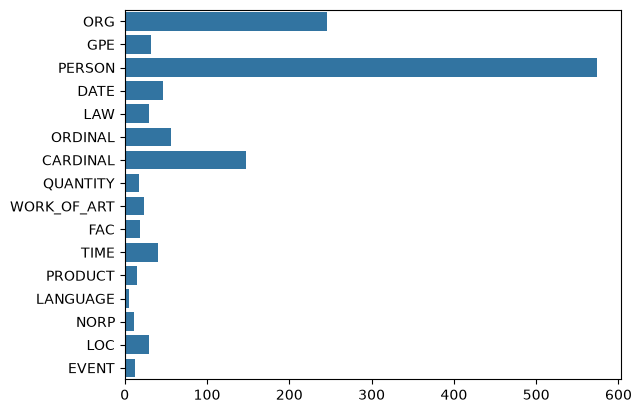

In [132]:
sns.barplot(count_labels_in_text, orient="h")
plt.show()

In [139]:
alice_nlp.ents[0].text.strip()

"Alice's Adventures"

In [140]:
person_counts = Counter(
    ent.text.strip()  # removes whitespaces
    for ent in alice_nlp.ents  # for each entity
    if ent.label_ == "PERSON"  # if the entity is a person
)
person_counts

Counter({'Alice': 340,
         'Hatter': 52,
         'Mouse': 27,
         'Queen': 22,
         'Bill': 14,
         'Majesty': 10,
         'Pigeon': 8,
         'William': 5,
         'King': 5,
         'Gryphon': 4,
         'Beau': 4,
         'Mabel': 3,
         'Mary Ann': 3,
         'Footman': 3,
         'Panther': 3,
         'Longitude': 2,
         "ALICE'S": 2,
         'Duck': 2,
         'Edwin': 2,
         'Mercia': 2,
         'Said': 2,
         'Pat': 2,
         'Miss': 2,
         'Pennyworth': 2,
         'Knave': 2,
         'Dormouse': 2,
         'Lewis Carroll': 1,
         'I. Down': 1,
         'Down': 1,
         'Latitude': 1,
         'Ada': 1,
         'Geography': 1,
         'else"--but': 1,
         'O Mouse': 1,
         'William the Conqueror': 1,
         'Ou': 1,
         'ma chatte': 1,
         'a Long Tale': 1,
         'Lory': 1,
         "I'LL": 1,
         'Morcar': 1,
         'Edgar Atheling': 1,
         'remedies--': 1,
         'C

In [141]:
common_per = [name[0] for name in person_counts.most_common(10)]
common_per

['Alice',
 'Hatter',
 'Mouse',
 'Queen',
 'Bill',
 'Majesty',
 'Pigeon',
 'William',
 'King',
 'Gryphon']

NLTK provides the `Text` class as a convenient wrapper around a list of tokens.  
It is designed for **linguistic exploration** of texts, offering methods for:
- concordance search (`.concordance()`),  
- context exploration (`.similar()` and `.common_contexts()`),  
- dispersion plots (`.dispersion_plot()`), and more.

Creating an `nltk.Text` object does **not** change the tokens
- it simply stores them in a structure that supports these advanced analyses.

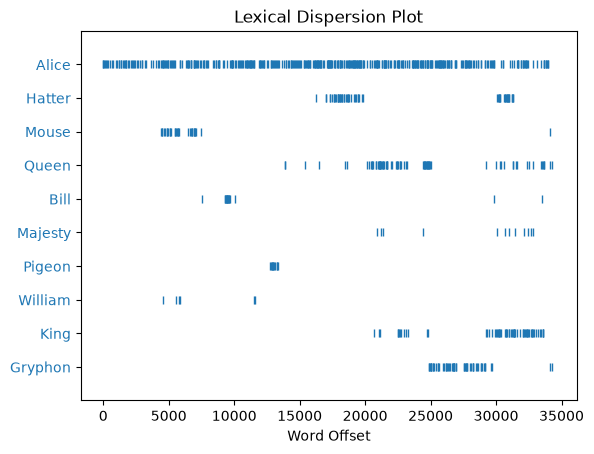

In [143]:
nltk_text = nltk.Text(tokens)
nltk_text.dispersion_plot(common_per)

### Chunking

Flat, non-overlapping noun phrases. No tree.

In [150]:
print(list(doc.noun_chunks))
print(list(nlp("She sells sea shells by the sea shore").noun_chunks))

[The quick fox, the lazy dog, Francesco Spinnato, a researcher, the University, Pisa, Pisa]
[She, sea shells, the sea shore]


### Dependency parsing

Every word points at its head; one word is the root.

In [151]:
displacy.render(nlp("The quick fox jumped over the lazy dog."),
                style="dep", jupyter=True, options={"compact": True})

## A pipeline

There is no default pipeline, only a pipeline for a task. Below, the same
text through two pipelines that disagree on purpose.

In [62]:
text = "The movie was NOT good, and I didn't enjoy the acting!!!"

NEGATIONS = {"not", "no", "nor", "n't", "never"}

def search_index(s):
    """For a search index: aggressive. Case and inflection are noise."""
    toks = nltk.word_tokenize(s.lower())
    toks = [t for t in toks if t.isalpha() and t not in sw]
    return [stemmer.stem(t) for t in toks]

def sentiment(s):
    """For sentiment: keep negation and punctuation. They carry the signal."""
    toks = nltk.word_tokenize(s.lower())
    drop = sw - NEGATIONS
    return [t for t in toks if t not in drop]

print("search   :", search_index(text))
print("sentiment:", sentiment(text))

search   : ['movi', 'good', 'enjoy', 'act']
sentiment: ['movie', 'not', 'good', ',', "n't", 'enjoy', 'acting', '!', '!', '!']


Look at what the first pipeline did to the sentence: it deleted **not**
and **didn't**. For retrieval that is fine. For sentiment it inverts the
meaning of the document, which is the whole thing we were trying to measure.

In [63]:
# your turn

## Exercise
Analyze the Bible using some of the techniques above. Focus on the New Testament, The Gospel of John

In [69]:
bible = gutenberg.raw("bible-kjv.txt")
print(bible[:200])

[The King James Bible]

The Old Testament of the King James Bible

The First Book of Moses:  Called Genesis


1:1 In the beginning God created the heaven and the earth.

1:2 And the earth was without 


In [72]:
len(bible)

4332554